In [20]:
# Write a Stan model file for Bernoulli data with Beta(3,4) prior on theta
stan_code = """
// bernoulli_beta.stan
data {
    int<lower=0> N;                  // number of trials
    array[N] int<lower=0, upper=1> y;
}

parameters {
    real<lower=0,upper=1> theta;     // success probability
}
model {
    theta ~ beta(3, 4);              // prior Beta(3,4)
    y ~ bernoulli(theta);            // likelihood
}
generated quantities {
    // int y_rep[N];
    array[N] int y_rep;
    for (n in 1:N)
        y_rep[n] = bernoulli_rng(theta); // posterior predictive draws
}
"""

stan_file = "bernoulli_beta_yndk.stan"
with open(stan_file, "w") as f:
        f.write(stan_code)

print(f"Wrote {stan_file}")
# To run this model, you would typically use a Stan interface like CmdStanPy or PyStan.


Wrote bernoulli_beta_yndk.stan


In [21]:
from cmdstanpy import CmdStanModel
import numpy as np

In [22]:
# Example data generated with p=0.7
N = 10
np.random.seed(42)  # For reproducibility
y = np.random.binomial(1, 0.7, size=N)
print("Example data y:", y)

Example data y: [1 0 0 1 1 1 1 0 1 0]


In [23]:
# Compile Stan model
model = CmdStanModel(stan_file='my_stan_file.stan')

# Run MCMC
fit = model.sample(data={'N': N, 'y': y})

12:19:36 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:19:36 - cmdstanpy - INFO - CmdStan done processing.


In [24]:
# Print summary
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-8.673740,0.018116,0.747127,0.303886,-10.192300,-8.371550,-8.152110,1874.97,2084.77,124998.0,1.00204
theta,0.585644,0.003467,0.136499,0.138164,0.354833,0.588529,0.806048,1544.25,1676.81,102950.0,1.00193


In [25]:
theta_samples = fit.stan_variable('theta')
print(theta_samples.shape, theta_samples)

(4000,) [0.66290977 0.66290977 0.57813186 ... 0.54434312 0.7019978  0.72471402]


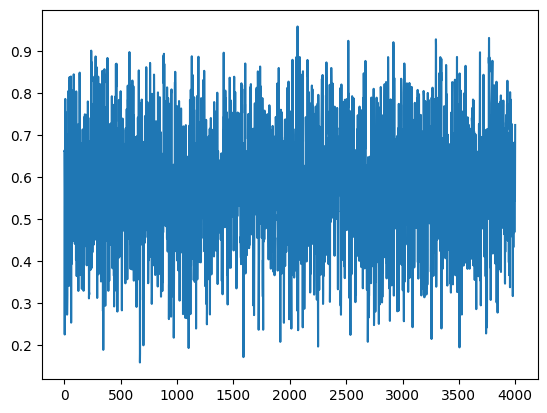

In [26]:
import matplotlib.pyplot as plt
plt.plot(theta_samples)

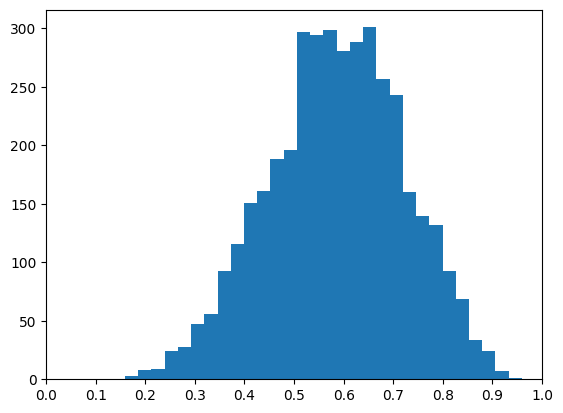

In [27]:
plt.hist(theta_samples, bins=30)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.05, 0.1))
plt.show()

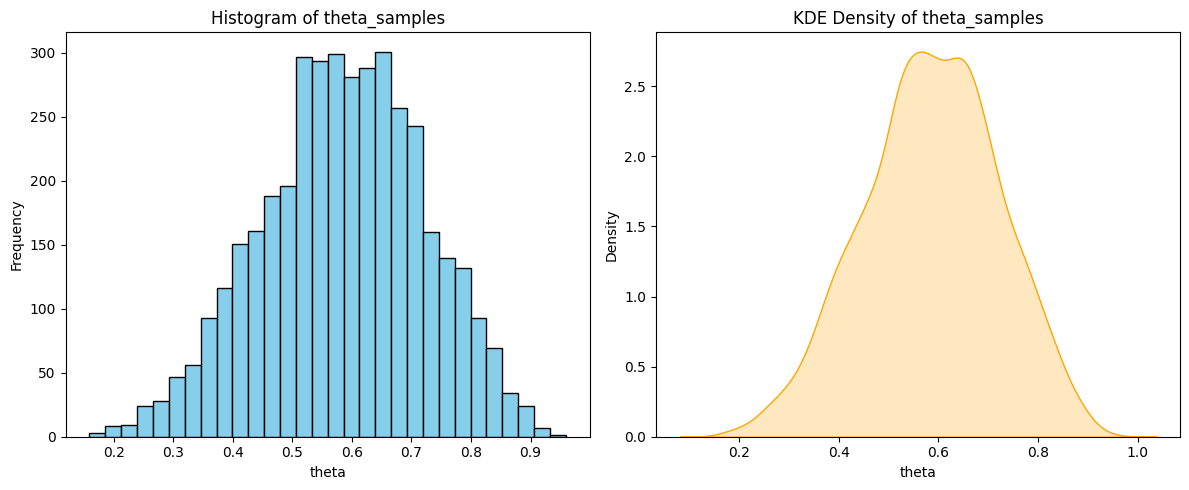

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(theta_samples, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of theta_samples')
axes[0].set_xlabel('theta')
axes[0].set_ylabel('Frequency')
sns.kdeplot(theta_samples, ax=axes[1], fill=True, color='orange')
axes[1].set_title('KDE Density of theta_samples')
axes[1].set_xlabel('theta')
axes[1].set_ylabel('Density')
plt.tight_layout()

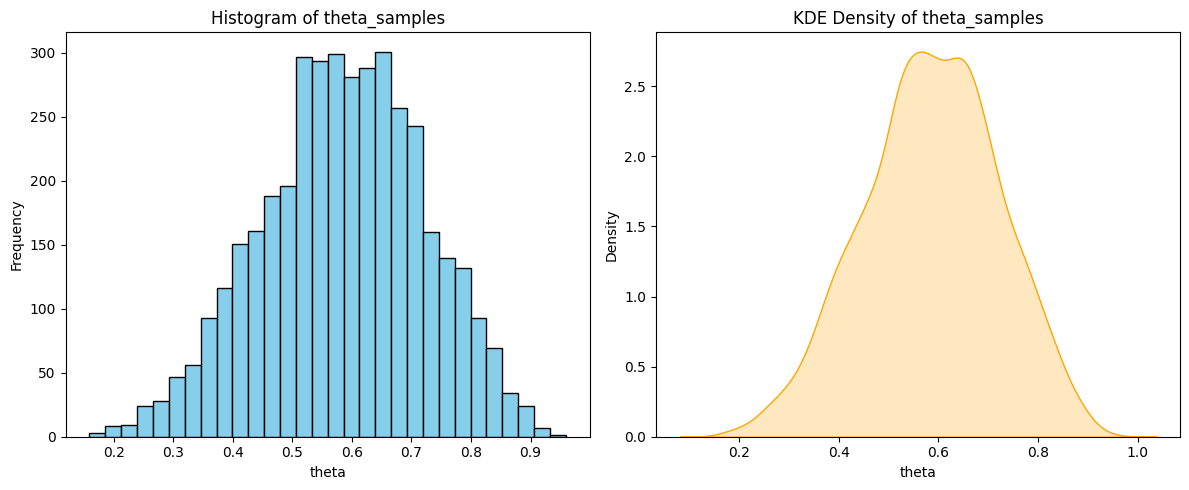

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(theta_samples, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of theta_samples')
axes[0].set_xlabel('theta')
axes[0].set_ylabel('Frequency')
sns.kdeplot(theta_samples, ax=axes[1], fill=True, color='orange')
axes[1].set_title('KDE Density of theta_samples')
axes[1].set_xlabel('theta')
axes[1].set_ylabel('Density')
plt.tight_layout()

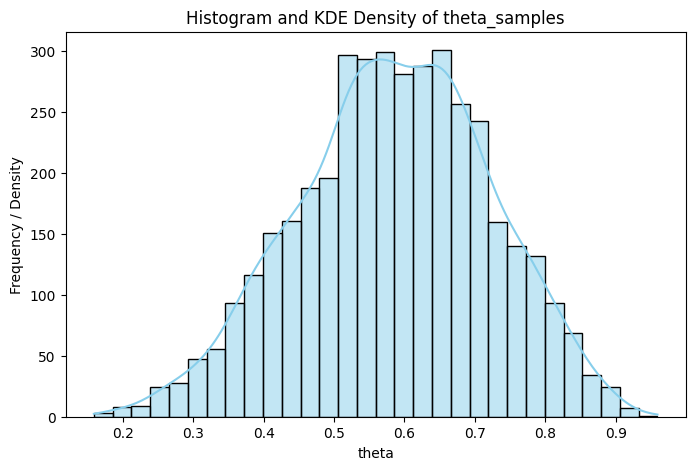

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(theta_samples, bins=30, color='skyblue', edgecolor='black', kde=True)
plt.title('Histogram and KDE Density of theta_samples')
plt.xlabel('theta')
plt.ylabel('Frequency / Density')
plt.show()

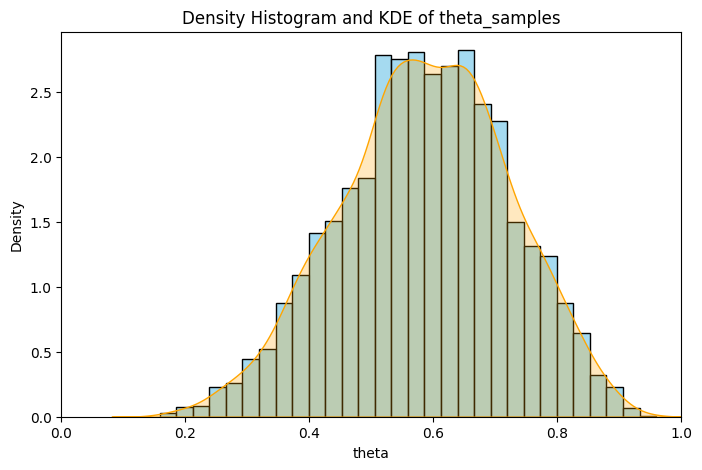

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(theta_samples, bins=30, color='skyblue', edgecolor='black', stat='density')
sns.kdeplot(theta_samples, color='orange', fill=True)
plt.title('Density Histogram and KDE of theta_samples')
plt.xlabel('theta')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.show()

In [32]:
theta_samples.min(), y

(np.float64(0.15886088), array([1, 0, 0, 1, 1, 1, 1, 0, 1, 0]))

In [33]:
theta_samples.min() / len(theta_samples)

np.float64(3.9715220000000004e-05)

1. the value of theta may be as small as 0.137.
2. Pr[.4 < theta < .6] = .57

In [34]:
a = (0.4 < theta_samples) & (theta_samples < 0.6)
a, a.sum(), a.sum() / len(theta_samples)

(array([False, False,  True, ...,  True, False, False], shape=(4000,)),
 np.int64(1735),
 np.float64(0.43375))

In [35]:
# Find the range of theta where 90% of the posterior samples lie.

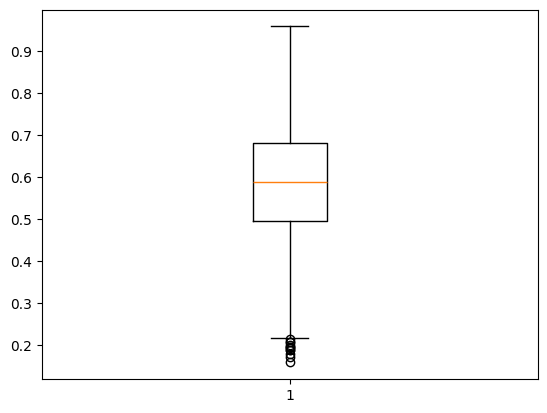

In [36]:
# box plot

plt.boxplot(theta_samples)
plt.show()

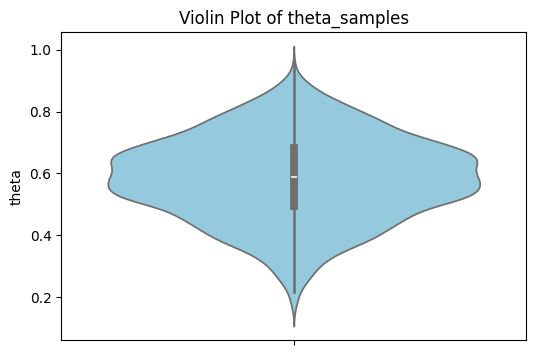

In [37]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.violinplot(y=theta_samples, color='skyblue')
plt.title('Violin Plot of theta_samples')
plt.ylabel('theta')
plt.show()